Pooled dataset size: 1139 unlabeled heights

Iter  mu1 (Child)   mu2 (Fathers) sigma1^2    sigma2^2    pi1     pi2     Log-Likelihood  
------------------------------------------------------------------------------------------
0     64.5000       70.0000       12.7241     12.7241     0.5000  0.5000  -3119.8222      
1     65.2205       69.2054       9.0603      8.4468      0.5011  0.4989  -3057.9135      
2     65.1609       69.2600       8.9420      8.1040      0.5005  0.4995  -3056.9719      
3     65.1021       69.3181       8.7356      7.8243      0.5004  0.4996  -3056.0043      
4     65.0436       69.3772       8.4920      7.5653      0.5004  0.4996  -3054.9756      
5     64.9858       69.4356       8.2332      7.3137      0.5005  0.4995  -3053.9037      
6     64.9295       69.4921       7.9705      7.0682      0.5005  0.4995  -3052.8229      
7     64.8755       69.5453       7.7116      6.8320      0.5004  0.4996  -3051.7754      
8     64.8246       69.5943       7.4631     

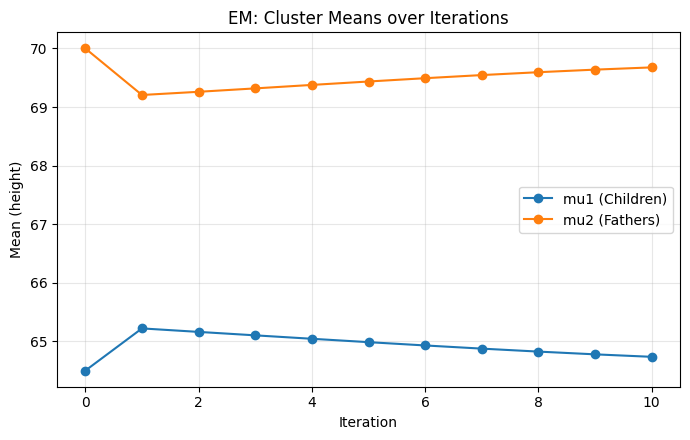

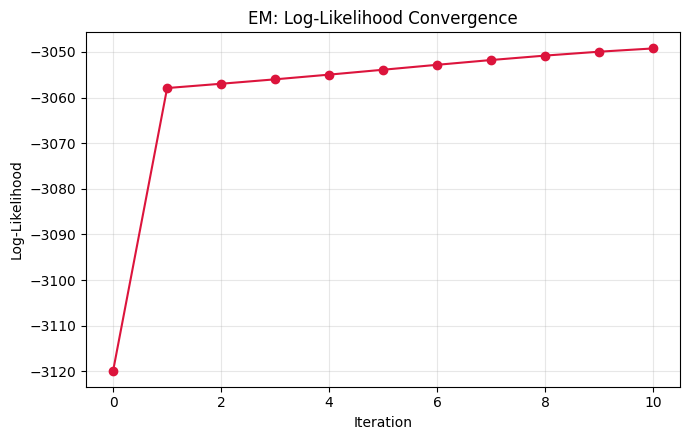

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# 0. DATA LOADING
# -------------------------------------------------------------------
def load_data(csv_path="GaltonFamilies.csv"):
    
    df = pd.read_csv(csv_path)

    parent_col = "father"   # change to "mother" to compare Mothers vs Children instead
    parents = df.drop_duplicates("family")[parent_col].to_numpy()
    children = df["childHeight"].to_numpy()

    # Pool them together, unlabeled -- this is the array EM will see.
    data = np.concatenate([children, parents])
    rng = np.random.default_rng(0)
    rng.shuffle(data)

    # We keep the true labels ONLY for our own sanity-checking/plots later,
    # EM itself never gets to see this.
    return data, children, parents



def gaussian_pdf(x, mu, sigma2):
    """Univariate Gaussian probability density function."""
    sigma2 = max(sigma2, 1e-6)  # numerical floor, avoid div-by-zero
    coeff = 1.0 / np.sqrt(2 * np.pi * sigma2)
    exponent = -((x - mu) ** 2) / (2 * sigma2)
    return coeff * np.exp(exponent)



def e_step(x, mu1, mu2, sigma1_2, sigma2_2, pi1, pi2):
    """
    Returns gamma1, gamma2: the posterior probability each point in x
    belongs to component 1 (Children) vs component 2 (Fathers).
    This is literally Bayes' theorem applied per-point.
    """
    p1 = pi1 * gaussian_pdf(x, mu1, sigma1_2)
    p2 = pi2 * gaussian_pdf(x, mu2, sigma2_2)
    total = p1 + p2
    total = np.where(total == 0, 1e-12, total)  # avoid div-by-zero

    gamma1 = p1 / total
    gamma2 = p2 / total
    return gamma1, gamma2



def m_step(x, gamma1, gamma2):
    n = len(x)
    N1 = gamma1.sum()
    N2 = gamma2.sum()

    mu1 = np.sum(gamma1 * x) / N1
    mu2 = np.sum(gamma2 * x) / N2

    sigma1_2 = np.sum(gamma1 * (x - mu1) ** 2) / N1
    sigma2_2 = np.sum(gamma2 * (x - mu2) ** 2) / N2

    pi1 = N1 / n
    pi2 = N2 / n

    return mu1, mu2, sigma1_2, sigma2_2, pi1, pi2



def log_likelihood(x, mu1, mu2, sigma1_2, sigma2_2, pi1, pi2):
    total = pi1 * gaussian_pdf(x, mu1, sigma1_2) + pi2 * gaussian_pdf(x, mu2, sigma2_2)
    total = np.where(total == 0, 1e-12, total)
    return np.sum(np.log(total))



def run_em(x, n_iter=10, verbose=True):
    
    
    mu1 = np.percentile(x, 25)
    mu2 = np.percentile(x, 75)
    sigma1_2 = np.var(x)
    sigma2_2 = np.var(x)
    pi1 = 0.5
    pi2 = 0.5

    history = []
    ll = log_likelihood(x, mu1, mu2, sigma1_2, sigma2_2, pi1, pi2)
    history.append(dict(iter=0, mu1=mu1, mu2=mu2, sigma1_2=sigma1_2,
                         sigma2_2=sigma2_2, pi1=pi1, pi2=pi2, ll=ll))

    for i in range(1, n_iter + 1):
        gamma1, gamma2 = e_step(x, mu1, mu2, sigma1_2, sigma2_2, pi1, pi2)
        mu1, mu2, sigma1_2, sigma2_2, pi1, pi2 = m_step(x, gamma1, gamma2)
        ll = log_likelihood(x, mu1, mu2, sigma1_2, sigma2_2, pi1, pi2)

        history.append(dict(iter=i, mu1=mu1, mu2=mu2, sigma1_2=sigma1_2,
                             sigma2_2=sigma2_2, pi1=pi1, pi2=pi2, ll=ll))

    if verbose:
        print_tracking_table(history)

    final_params = dict(mu1=mu1, mu2=mu2, sigma1_2=sigma1_2,
                         sigma2_2=sigma2_2, pi1=pi1, pi2=pi2)
    return history, final_params


def print_tracking_table(history):
    header = f"{'Iter':<6}{'mu1 (Child)':<14}{'mu2 (Fathers)':<14}{'sigma1^2':<12}{'sigma2^2':<12}{'pi1':<8}{'pi2':<8}{'Log-Likelihood':<16}"
    print(header)
    print("-" * len(header))
    for row in history:
        print(f"{row['iter']:<6}{row['mu1']:<14.4f}{row['mu2']:<14.4f}"
              f"{row['sigma1_2']:<12.4f}{row['sigma2_2']:<12.4f}"
              f"{row['pi1']:<8.4f}{row['pi2']:<8.4f}{row['ll']:<16.4f}")



def classify(new_height, params):
    """
    Given ONE new height and the FINAL fitted EM parameters, returns the
    posterior probability it's a Child vs a Father.
    This is just one call to e_step on a single-point array.
    """
    x = np.array([new_height])
    g1, g2 = e_step(x, params["mu1"], params["mu2"],
                     params["sigma1_2"], params["sigma2_2"],
                     params["pi1"], params["pi2"])
    p_child = g1[0]
    p_parent = g2[0]
    print(f"\nTest height: {new_height}")
    print(f"  P(Child)        = {p_child:.4f}")
    print(f"  P(Father)        = {p_parent:.4f}")
    return p_child, p_parent



def plot_convergence(history):
    iters = [h["iter"] for h in history]
    mu1s = [h["mu1"] for h in history]
    mu2s = [h["mu2"] for h in history]
    lls = [h["ll"] for h in history]

    fig1, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.plot(iters, mu1s, marker="o", label="mu1 (Children)")
    ax1.plot(iters, mu2s, marker="o", label="mu2 (Fathers)")
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Mean (height)")
    ax1.set_title("EM: Cluster Means over Iterations")
    ax1.legend()
    ax1.grid(alpha=0.3)
    fig1.tight_layout()
    fig1.savefig("part1_means_over_iterations.png", dpi=150)

    fig2, ax2 = plt.subplots(figsize=(7, 4.5))
    ax2.plot(iters, lls, marker="o", color="crimson")
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("Log-Likelihood")
    ax2.set_title("EM: Log-Likelihood Convergence")
    ax2.grid(alpha=0.3)
    fig2.tight_layout()
    fig2.savefig("part1_loglikelihood_over_iterations.png", dpi=150)

    print("\nSaved plots:")
    print("  part1_means_over_iterations.png")
    print("  part1_loglikelihood_over_iterations.png")



if __name__ == "__main__":
    
    data, true_children, true_parents = load_data()

    print(f"Pooled dataset size: {len(data)} unlabeled heights\n")

    history, final_params = run_em(data, n_iter=10)

    print("\nFinal fitted parameters:")
    for k, v in final_params.items():
        print(f"  {k} = {v:.4f}")

    
    global_mean = np.mean(data)
    pile1 = data[data < global_mean]
    pile2 = data[data >= global_mean]
    print(f"\n[Naive mean-split check] Global mean = {global_mean:.2f}")
    print(f"  Naive pile1 mean = {pile1.mean():.2f}  (n={len(pile1)})")
    print(f"  Naive pile2 mean = {pile2.mean():.2f}  (n={len(pile2)})")
    print("  Compare these to EM's mu1/mu2 above -- discuss overlap & bias "
          "from hard-thresholding in your presentation.")

    plot_convergence(history)

    
    test_height = 68  
    classify(test_height, final_params)


In [ ]:
import csv
import os
import re


def load_data(csv_path="IMDB_Dataset.csv", text_col="review", label_col="sentiment"):
    """
    Loads the real IMDb Movie Reviews dataset (50,000 reviews).
    In Colab: just upload IMDB_Dataset.csv to the working directory
    (or mount Drive and update the path) -- this function will find it.
    """
    reviews = []
    with open(csv_path, newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            text = row[text_col].lower()
            label = row[label_col].strip().lower()
            reviews.append((text, label))
    return reviews



POSITIVE_KEYWORDS = ["excellent", "brilliant", "masterpiece", "love"]
NEGATIVE_KEYWORDS = ["boring", "waste", "awful", "worst"]
ALL_KEYWORDS = POSITIVE_KEYWORDS + NEGATIVE_KEYWORDS


def contains_keyword(text, keyword):
    """Simple whole-word containment check using basic Python (regex module is stdlib)."""
    return re.search(rf"\b{re.escape(keyword)}\b", text) is not None



def bayes_for_keyword(reviews, keyword):
    """
    Computes and returns:
        prior       P(Positive)
        likelihood  P(keyword | Positive)
        marginal    P(keyword)
        posterior   P(Positive | keyword)
    using plain counting -- no external libraries.
    """
    total = len(reviews)
    n_positive = sum(1 for _, label in reviews if label == "positive")

    prior = n_positive / total

    pos_with_kw = sum(1 for text, label in reviews
                       if label == "positive" and contains_keyword(text, keyword))
    likelihood = pos_with_kw / n_positive if n_positive > 0 else 0.0

    n_with_kw = sum(1 for text, _ in reviews if contains_keyword(text, keyword))
    marginal = n_with_kw / total if total > 0 else 0.0

    if marginal == 0:
        posterior = 0.0
    else:
       
        posterior = (likelihood * prior) / marginal

    return {
        "keyword": keyword,
        "prior": prior,
        "likelihood": likelihood,
        "marginal": marginal,
        "posterior": posterior,
        "n_with_kw": n_with_kw,
    }



def print_results_table(results):
    header = f"{'Keyword':<14}{'P(Positive)':<14}{'P(kw|Pos)':<14}{'P(kw)':<12}{'P(Pos|kw)':<12}{'n(kw)':<8}"
    print(header)
    print("-" * len(header))
    for r in results:
        print(f"{r['keyword']:<14}{r['prior']:<14.4f}{r['likelihood']:<14.4f}"
              f"{r['marginal']:<12.4f}{r['posterior']:<12.4f}{r['n_with_kw']:<8}")


if __name__ == "__main__":
   
    reviews = load_data('/content/IMDB Dataset.csv')

    print(f"Loaded {len(reviews)} reviews "
          f"({sum(1 for _,l in reviews if l=='positive')} positive, "
          f"{sum(1 for _,l in reviews if l=='negative')} negative)\n")

    print("=== Keywords chosen as POSITIVE indicators ===")
    pos_results = [bayes_for_keyword(reviews, kw) for kw in POSITIVE_KEYWORDS]
    print_results_table(pos_results)

    print("\n=== Keywords chosen as NEGATIVE indicators ===")
    neg_results = [bayes_for_keyword(reviews, kw) for kw in NEGATIVE_KEYWORDS]
    print_results_table(neg_results)

    print("\nInterpretation: for positive-indicator keywords we expect P(Positive|keyword) "
          "to be well ABOVE the prior P(Positive); for negative-indicator keywords we expect "
          "P(Positive|keyword) to be well BELOW the prior -- discuss this contrast in your presentation.")

Loaded 50000 reviews (25000 positive, 25000 negative)

=== Keywords chosen as POSITIVE indicators ===
Keyword       P(Positive)   P(kw|Pos)     P(kw)       P(Pos|kw)   n(kw)   
--------------------------------------------------------------------------
excellent     0.5000        0.1147        0.0710      0.8074      3552    
brilliant     0.5000        0.0635        0.0418      0.7601      2088    
masterpiece   0.5000        0.0351        0.0241      0.7274      1207    
love          0.5000        0.2266        0.1785      0.6349      8924    

=== Keywords chosen as NEGATIVE indicators ===
Keyword       P(Positive)   P(kw|Pos)     P(kw)       P(Pos|kw)   n(kw)   
--------------------------------------------------------------------------
boring        0.5000        0.0236        0.0610      0.1937      3051    
waste         0.5000        0.0070        0.0507      0.0691      2534    
awful         0.5000        0.0114        0.0577      0.0985      2883    
worst         0.5000     

Initial: m=[-1.  2.], b=[1. 1.], cost=61.0000


--- Iteration 1 ---
  Forward Pass:  yhat = [ 6. 17.]
  Error:         err  = [ 1. 11.]
  Loss (MSE):    J    = 61.000000
  Backward Pass: dJ/dm1=45.000009, dJ/dm2=113.000055, dJ/db1=1.000001, dJ/db2=11.000001
  Update:        m = [-1.45000009  0.86999945], b = [0.98999999 0.88999999]  ->  new cost = 6.503318

--- Iteration 2 ---
  Forward Pass:  yhat = [2.14999827 3.7899942 ]
  Error:         err  = [-2.85000173 -2.2100058 ]
  Loss (MSE):    J    = 6.503318
  Backward Pass: dJ/dm1=-11.690016, dJ/dm2=-30.650009, dJ/db1=-2.850001, dJ/db2=-2.210005
  Update:        m = [-1.33309992  1.17649954], b = [1.01850001 0.91210005]  ->  new cost = 2.497397

--- Iteration 3 ---
  Forward Pass:  yhat = [3.21489871 7.34469578]
  Error:         err  = [-1.78510129  1.34469578]
  Loss (MSE):    J    = 2.497397
  Backward Pass: dJ/dm1=3.593690, dJ/dm2=8.091708, dJ/db1=-1.785101, dJ/db2=1.344696
  Update:        m = [-1.36903682  1.09558246], b = [1.036351

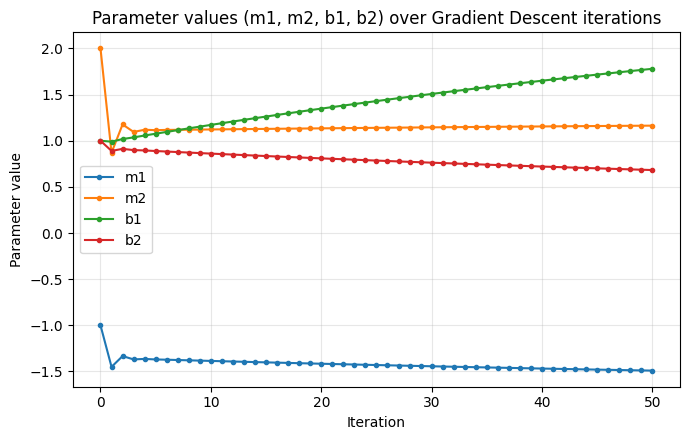

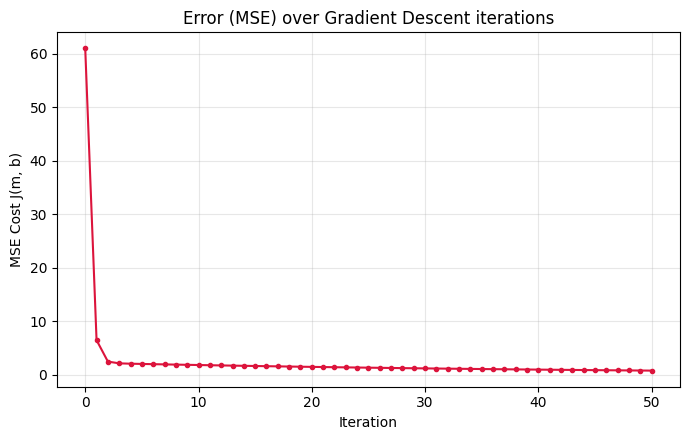

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

X = np.array([[1.0, 3.0],
              [4.0, 10.0]])
y = np.array([5.0, 6.0])

m_init = np.array([-1.0, 2.0])
b_init = np.array([1.0, 1.0])  
ALPHA = 0.01
N_ITERS = 50  
def predict(X, m, b):
    """yhat = X·m + b (elementwise: yhat_i = m1*x1_i + m2*x2_i + b_i)."""
    return X @ m + b


def mse_cost(params, X, y):
    """
    params is a flat vector [m1, m2, b1, b2] so SciPy's derivative utilities
    (which expect a flat parameter vector) can differentiate through it.
    Note: b is now length-2 (one bias per data point), so params has 4 entries total.
    """
    m = params[:2]
    b = params[2:]
    yhat = predict(X, m, b)
    return np.mean((yhat - y) ** 2)



def compute_gradient_scipy(m, b, X, y, epsilon=1e-6):
    """
    Wraps SciPy's approx_fprime (central-difference numerical derivative)
    to compute dJ/dm (length 2) and dJ/db (length 2), without hand-deriving
    the formula in code (SciPy differentiates the cost function directly).
    """
    params = np.concatenate([m, b])
    grad = approx_fprime(params, mse_cost, epsilon, X, y)
    grad_m = grad[:2]
    grad_b = grad[2:]
    return grad_m, grad_b



def run_gradient_descent(X, y, m, b, alpha, n_iters):
    m_history = [m.copy()]
    b_history = [b.copy()]
    cost_history = [mse_cost(np.concatenate([m, b]), X, y)]
    n = len(y)

    for i in range(1, n_iters + 1):
       
        yhat = predict(X, m, b)

        
        err = yhat - y

        
        cost_before = np.mean(err ** 2)

        
        grad_m, grad_b = compute_gradient_scipy(m, b, X, y)
       
        m = m - alpha * grad_m
        b = b - alpha * grad_b

        cost = mse_cost(np.concatenate([m, b]), X, y)

        m_history.append(m.copy())
        b_history.append(b.copy())
        cost_history.append(cost)

        if i <= 4:  
            print(f"\n--- Iteration {i} ---")
            print(f"  Forward Pass:  yhat = {yhat}")
            print(f"  Error:         err  = {err}")
            print(f"  Loss (MSE):    J    = {cost_before:.6f}")
            print(f"  Backward Pass: dJ/dm1={grad_m[0]:.6f}, dJ/dm2={grad_m[1]:.6f}, "
                  f"dJ/db1={grad_b[0]:.6f}, dJ/db2={grad_b[1]:.6f}")
            print(f"  Update:        m = {m}, b = {b}  ->  new cost = {cost:.6f}")

    return np.array(m_history), np.array(b_history), np.array(cost_history)



def plot_results(m_history, b_history, cost_history):
    iterations = np.arange(len(cost_history))

    fig1, ax1 = plt.subplots(figsize=(7, 4.5))
    ax1.plot(iterations, m_history[:, 0], label="m1", marker="o", markersize=3)
    ax1.plot(iterations, m_history[:, 1], label="m2", marker="o", markersize=3)
    ax1.plot(iterations, b_history[:, 0], label="b1", marker="o", markersize=3)
    ax1.plot(iterations, b_history[:, 1], label="b2", marker="o", markersize=3)
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Parameter value")
    ax1.set_title("Parameter values (m1, m2, b1, b2) over Gradient Descent iterations")
    ax1.legend()
    ax1.grid(alpha=0.3)
    fig1.tight_layout()
    fig1.savefig("part4_parameters_over_iterations.png", dpi=150)

    fig2, ax2 = plt.subplots(figsize=(7, 4.5))
    ax2.plot(iterations, cost_history, color="crimson", marker="o", markersize=3)
    ax2.set_xlabel("Iteration")
    ax2.set_ylabel("MSE Cost J(m, b)")
    ax2.set_title("Error (MSE) over Gradient Descent iterations")
    ax2.grid(alpha=0.3)
    fig2.tight_layout()
    fig2.savefig("part4_error_over_iterations.png", dpi=150)

    print("\nSaved plots:")
    print("  part4_parameters_over_iterations.png")
    print("  part4_error_over_iterations.png")



if __name__ == "__main__":
    print(f"Initial: m={m_init}, b={b_init}, "
          f"cost={mse_cost(np.concatenate([m_init, b_init]), X, y):.4f}\n")

    m_hist, b_hist, cost_hist = run_gradient_descent(X, y, m_init, b_init, ALPHA, N_ITERS)

    print(f"\nFinal (after {N_ITERS} iterations): m={m_hist[-1]}, b={b_hist[-1]}, "
          f"cost={cost_hist[-1]:.6f}")

    final_predictions = predict(X, m_hist[-1], b_hist[-1])
    print(f"Final predictions: {final_predictions}  (targets were: {y})")

    plot_results(m_hist, b_hist, cost_hist)
